# Derivatives

深度学习微积分第一课：从极限定义（第一性原理）出发理解导数，逐步推导常用函数导数与全部求导法则（含链式法则证明），再用数值微分和 PyTorch autograd 双重交叉验证，最后落到梯度下降——理解"为什么负梯度方向就是学习方向"。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib

# 中文字体：避免图上中文显示为方块（macOS 用苹方，Windows 用微软雅黑）
matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修复负号显示为方块

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 导数到底是什么：从平均变化率到瞬时变化率


### 1.1 平均变化率（割线斜率）

考虑函数 $f(x) = x^2$ 在 $x_0 = 1$ 附近的变化。取一个步长 $h$，区间 $[x_0, x_0+h]$ 上的**平均变化率**是割线斜率：

$$\frac{f(x_0+h)-f(x_0)}{h}$$

$h$ 越小，割线越贴近 $x_0$ 处的切线。下面画出 $h = 2, 1, 0.5, 0.1$ 的割线，观察斜率如何逼近切线斜率（$f'(1)=2$）。


Text(0.5, 1.0, '割线斜率随 h 缩小 → 逼近切线斜率（导数）')

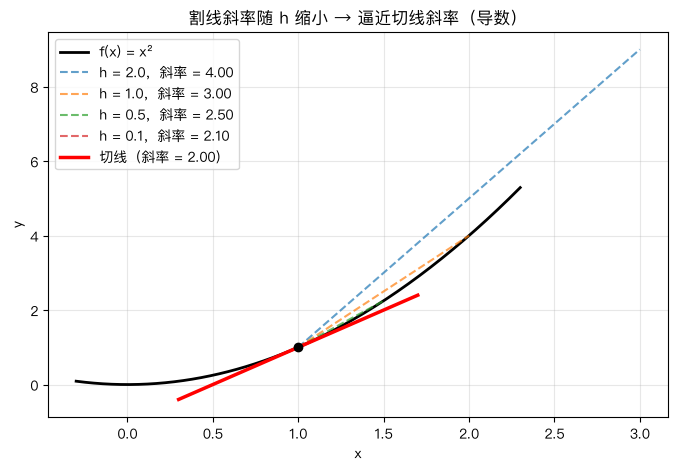

In [2]:
def f(x):
    return x ** 2

x0 = 1.0
xs = np.linspace(-0.3, 2.3, 200)

plt.figure(figsize=(8, 5))
plt.plot(xs, f(xs), 'k-', linewidth=2, label='f(x) = x²')

for h in [2.0, 1.0, 0.5, 0.1]:
    x1 = x0 + h
    slope = (f(x1) - f(x0)) / h          # 割线斜率 = 平均变化率
    plt.plot([x0, x1], [f(x0), f(x1)], '--', alpha=0.7,
             label=f'h = {h}，斜率 = {slope:.2f}')

# 切线：f'(1) = 2
xt = np.linspace(0.3, 1.7, 10)
plt.plot(xt, f(x0) + 2 * (xt - x0), 'r-', linewidth=2.5, label='切线（斜率 = 2.00）')

plt.scatter([x0], [f(x0)], color='black', zorder=5)
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3)
plt.title('割线斜率随 h 缩小 → 逼近切线斜率（导数）')


### 1.2 瞬时变化率：极限定义（第一性原理）

$h = 0$ 时割线公式是 0/0，无意义。导数是**让 $h$ 无限逼近 0 时割线斜率的极限**：

$$f'(x) = \lim_{h \to 0} \frac{f(x+h)-f(x)}{h}$$

关键点：不是"把 $h$ 设成 0"，而是"看 $h$ 趋近 0 时比值逼近哪个数"。只要这个极限存在，比值就被固定下来，不再依赖 $h$。


### 1.3 用极限定义手推两个经典导数

**① $(x^2)' = 2x$**

$$\frac{(x+h)^2 - x^2}{h} = \frac{2xh + h^2}{h} = 2x + h \;\xrightarrow{h\to0}\; 2x$$

**② $(e^x)' = e^x$**：先看关键极限 $\lim_{h\to0}\frac{e^h-1}{h}=1$（欧拉数 $e$ 的定义性质之一），于是

$$\frac{e^{x+h}-e^x}{h} = e^x \cdot \frac{e^h-1}{h} \;\xrightarrow{h\to0}\; e^x \cdot 1 = e^x$$

下面用数值逼近验证这个关键极限。


In [3]:
hs = np.array([1.0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7])
ratios = (np.exp(hs) - 1) / hs          # (e^h - 1) / h
for h, r in zip(hs, ratios):
    print(f"h = {h:9.1e}   (e^h - 1)/h = {r:.10f}")
print("\n极限 = 1 ⟹ (eˣ)' = eˣ · 1 = eˣ")


h =   1.0e+00   (e^h - 1)/h = 1.7182818285
h =   1.0e-01   (e^h - 1)/h = 1.0517091808
h =   1.0e-02   (e^h - 1)/h = 1.0050167084
h =   1.0e-03   (e^h - 1)/h = 1.0005001667
h =   1.0e-04   (e^h - 1)/h = 1.0000500017
h =   1.0e-05   (e^h - 1)/h = 1.0000050000
h =   1.0e-06   (e^h - 1)/h = 1.0000005000
h =   1.0e-07   (e^h - 1)/h = 1.0000000494

极限 = 1 ⟹ (eˣ)' = eˣ · 1 = eˣ


## 2. 常见函数的导数


| 函数 | 导数 | 一句话直觉 |
|------|------|-----------|
| $x^n$ | $n\,x^{n-1}$ | 幂次挪到前面当系数，指数减一 |
| $e^x$ | $e^x$ | 增长率和自身成正比 |
| $a^x$ | $a^x\ln a$ | 底数不是 $e$ 时多乘一个 $\ln a$ |
| $\ln x$ | $1/x$ | 对数增长率随 $x$ 反比衰减 |
| $\sin x$ | $\cos x$ | 正弦的瞬时变化率是余弦 |
| $\cos x$ | $-\sin x$ | 余弦的瞬时变化率是负正弦 |

下面的代码用**中心差分**数值求导，逐条验证这些公式（数值 vs 解析）。


In [4]:
def central_diff(f, x, h=1e-6):
    """中心差分：O(h²) 精度，误差分析见第 5 节"""
    return (f(x + h) - f(x - h)) / (2 * h)

table = {
    "x³":    (lambda x: x**3,        lambda x: 3*x**2),
    "eˣ":    (np.exp,                np.exp),
    "2ˣ":    (lambda x: 2**x,        lambda x: 2**x * np.log(2)),
    "ln x":  (np.log,                lambda x: 1/x),
    "sin x": (np.sin,                np.cos),
    "cos x": (np.cos,                lambda x: -np.sin(x)),
}

x = 0.7
print(f"{'函数':<7}{'解析值':>16}{'数值值':>16}{'误差':>12}")
for name, (f, df) in table.items():
    analytic, numeric = df(x), central_diff(f, x)
    print(f"{name:<7}{analytic:>16.10f}{numeric:>16.10f}{abs(analytic-numeric):>12.2e}")


函数                  解析值             数值值          误差
x³         1.4700000000    1.4700000000    3.12e-11
eˣ         2.0137527075    2.0137527075    4.36e-12
2ˣ         1.1260209169    1.1260209170    7.80e-11
ln x       1.4285714286    1.4285714286    2.52e-11
sin x      0.7648421873    0.7648421873    2.18e-11
cos x     -0.6442176872   -0.6442176873    1.35e-11


## 3. 求导法则（含证明）


### 3.1 线性法则

$$(cf)' = c\,f', \qquad (f+g)' = f' + g'$$

直接由极限定义得到：常系数 $c$ 可提出极限号；和的极限等于极限的和。线性法则是神经网络损失函数可加性的基础——batch 平均损失就是单样本损失的线性组合，梯度自然也是平均。


### 3.2 乘法法则（莱布尼茨法则）

$$(fg)' = f'g + fg'$$

**证明（极限定义）**：往分子里加减 $f(x)g(x+h)$，凑出两个差分：

$$\frac{f(x{+}h)g(x{+}h) - f(x)g(x)}{h} = \frac{[f(x{+}h)-f(x)]\,g(x{+}h) + f(x)\,[g(x{+}h)-g(x)]}{h}$$

取极限：第一项 $\to f'(x)g(x)$（$g$ 连续，故 $g(x+h)\to g(x)$），第二项 $\to f(x)g'(x)$。

**直觉**：矩形面积 $A = f\cdot g$，$f$ 变 $\Delta f$、$g$ 变 $\Delta g$，面积增量 $= f\Delta g + g\Delta f + \Delta f\Delta g$，忽略二阶小量 $\Delta f\Delta g$ 即得。代码验证：


In [5]:
x = 1.3
f, g = lambda t: np.sin(t), lambda t: t**2

numeric = central_diff(lambda t: f(t) * g(t), x)   # (fg)' 的数值值
formula = np.cos(x) * g(x) + f(x) * (2 * x)        # f'g + fg' 法则值
print(f"(sin x · x²)' 数值值 = {numeric:.10f}")
print(f"(sin x · x²)' 法则值 = {formula:.10f}")
print(f"误差 = {abs(numeric - formula):.2e}")


(sin x · x²)' 数值值 = 2.9573243022
(sin x · x²)' 法则值 = 2.9573243025
误差 = 2.38e-10


### 3.3 除法法则

$$\left(\frac{f}{g}\right)' = \frac{f'g - fg'}{g^2}$$

可由乘法法则 + 链式法则推出：$f/g = f\cdot(1/g)$，其中 $(1/g)' = -g'/g^2$（下面 3.4 推）。


### 3.4 链式法则：深度学习最重要的公式

$$(f \circ g)'(x) = f'\big(g(x)\big) \cdot g'(x)$$

**证明要点**：令 $\Delta g = g(x+h)-g(x)$，把差商改写为两个因子的乘积：

$$\frac{f(g(x{+}h)) - f(g(x))}{h} = \underbrace{\frac{f(g(x)+\Delta g) - f(g(x))}{\Delta g}}_{\to\; f'(g(x))} \cdot \underbrace{\frac{\Delta g}{h}}_{\to\; g'(x)}$$

（严谨处理需排除 $\Delta g = 0$ 的点，可用可去间断点补丁，结论不变。）

**为什么反向传播就是链式法则**：神经网络 $y = f(g(x))$，误差对 $x$ 的梯度 = 沿途局部导数相乘。误差从输出层往输入层"逐层乘回来"，每层只乘一个局部导数——这就是反向传播名字的由来，第 5 课（自动微分与反向传播）会完整展开。代码验证：


In [6]:
# y = sin(x² + 1)：外层 sin，内层 x²+1
x = 0.9
inner, outer = lambda t: t**2 + 1, np.sin

numeric  = central_diff(lambda t: outer(inner(t)), x)   # dy/dx 数值值
analytic = np.cos(inner(x)) * (2 * x)                    # f'(g)·g' 解析值
print(f"d/dx sin(x²+1) 数值值 = {numeric:.10f}")
print(f"d/dx sin(x²+1) 解析值 = {analytic:.10f}")
print(f"误差 = {abs(numeric - analytic):.2e}")


d/dx sin(x²+1) 数值值 = -0.4264722877
d/dx sin(x²+1) 解析值 = -0.4264722876
误差 = 1.88e-11


### 3.5 法则速查

| 场景 | 法则 | 结果 |
|------|------|------|
| 常数倍 | 线性 | $(3x^2)' = 6x$ |
| 加减 | 线性 | $(x^2+\sin x)' = 2x + \cos x$ |
| 相乘 | 乘法 | $(x^2 e^x)' = 2xe^x + x^2 e^x$ |
| 相除 | 除法 | $(\sin x / x)' = (x\cos x - \sin x)/x^2$ |
| 嵌套 | 链式 | $(e^{x^2})' = e^{x^2}\cdot 2x$ |


## 4. 高阶导数与泰勒展开


### 4.1 二阶导数：变化率的变化率

一阶导数 $f'$ 描述"函数在变多快"；二阶导数 $f''$ 描述"这个速度本身在变多快"（类比物理：速度 vs 加速度）。

- $f'' > 0$：凸（斜率递增，函数下凹）
- $f'' < 0$：凹（斜率递减，函数上凸）

二阶导数的符号就是判断损失曲面"碗口朝上还是朝下"的依据，也是后续 Hessian 矩阵（多元版二阶导）的雏形，对应 linear-algebra 07 的正定矩阵。


### 4.2 泰勒展开：用多项式逼近函数

$f$ 在 $x_0$ 附近可展开为：

$$f(x) \approx f(x_0) + f'(x_0)(x-x_0) + \tfrac{1}{2}f''(x_0)(x-x_0)^2 + \cdots$$

- **一阶近似**：切线，局部用直线代替曲线 → 梯度下降的理论依据（第 7 节）
- **二阶近似**：抛物线，多捕捉曲率信息 → 牛顿法 / Hessian 的理论依据

代码画出 $e^x$ 在 0 处的一阶、二阶逼近。


Text(0.5, 1.0, '泰勒展开：离 x₀ 越近，多项式越精确')

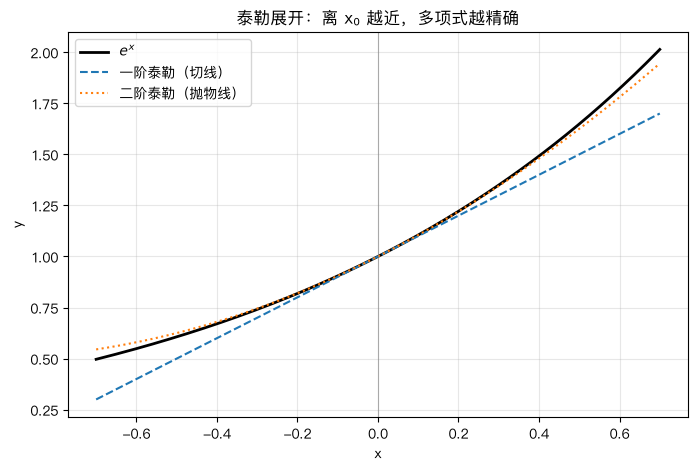

In [7]:
x0 = 0.0
xs = np.linspace(-0.7, 0.7, 200)
y  = np.exp(xs)
t1 = np.exp(x0) + np.exp(x0) * (xs - x0)          # 一阶泰勒（切线）
t2 = t1 + 0.5 * np.exp(x0) * (xs - x0)**2         # 二阶泰勒（抛物线）

plt.figure(figsize=(8, 5))
plt.plot(xs, y, 'k-', linewidth=2, label=r'$e^x$')
plt.plot(xs, t1, '--', label='一阶泰勒（切线）')
plt.plot(xs, t2, ':',  label='二阶泰勒（抛物线）')
plt.axvline(x0, color='gray', linestyle='-', linewidth=0.8, alpha=0.6)
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3)
plt.title('泰勒展开：离 x₀ 越近，多项式越精确')


## 5. 数值微分：机器怎么算导数


### 5.1 两种差分公式

| 方法 | 公式 | 截断误差 |
|------|------|---------|
| 前向差分 | $(f(x+h) - f(x))\,/\,h$ | $O(h)$ |
| 中心差分 | $(f(x+h) - f(x-h))\,/\,(2h)$ | $O(h^2)$ |

中心差分把采样点对称放在 $x$ 两侧，正负方向的截断误差互相抵消一部分，精度高一阶。


         h          前向误差          中心误差
   1.0e-01      1.41e-01      4.53e-03
   1.0e-02      1.36e-02      4.53e-05
   1.0e-03      1.36e-03      4.53e-07
   1.0e-04      1.36e-04      4.53e-09
   1.0e-05      1.36e-05      5.86e-11
   1.0e-06      1.36e-06      1.63e-10
   1.0e-07      1.40e-07      5.86e-11
   1.0e-08      6.60e-09      6.60e-09


Text(0.5, 1.0, 'log-log 图：斜率 = 误差阶数；h 过小后舍入误差反噬')

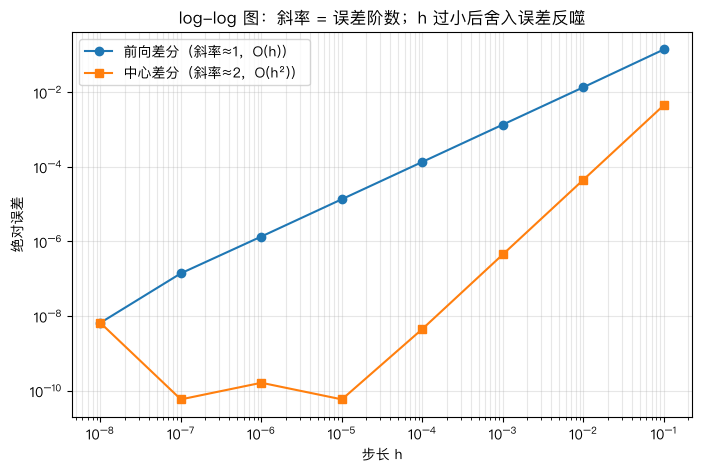

In [8]:
def forward_diff(f, x, h):
    return (f(x + h) - f(x)) / h

def central_diff2(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

x, f = 1.0, np.exp
true = np.exp(x)

hs = 10.0 ** np.arange(-1, -9, -1)
err_f = [abs(forward_diff(f, x, h) - true) for h in hs]
err_c = [abs(central_diff2(f, x, h) - true) for h in hs]

print(f"{'h':>10}  {'前向误差':>12}  {'中心误差':>12}")
for h, ef, ec in zip(hs, err_f, err_c):
    print(f"{h:10.1e}  {ef:12.2e}  {ec:12.2e}")

plt.figure(figsize=(8, 5))
plt.loglog(hs, err_f, 'o-', label='前向差分（斜率≈1，O(h)）')
plt.loglog(hs, err_c, 's-', label='中心差分（斜率≈2，O(h²)）')
plt.xlabel('步长 h'); plt.ylabel('绝对误差')
plt.legend(); plt.grid(alpha=0.3, which='both')
plt.title('log-log 图：斜率 = 误差阶数；h 过小后舍入误差反噬')


### 5.2 为什么深度学习不用数值微分

数值微分有两个硬伤：

1. **计算成本**：中心差分每个参数要 2 次前向传播，$n$ 个参数就是 $2n$ 次；百万参数的网络完全不可行。
2. **误差两难**：$h$ 太大截断误差大（$O(h^2)$），$h$ 太小舍入误差反噬（上图右端误差回升，float64 下中心差分最优 $h$ 约 $10^{-6}$）。

深度学习的答案是**自动微分（autograd）**：一次前向 + 一次反向，总成本约 3 倍前向，且是精确的链式法则乘积，不涉及差分。第 5 课将完整实现它。


## 6. 用 PyTorch autograd 交叉验证


### 6.1 一行 backward 拿到导数

PyTorch 用计算图自动执行链式法则。对张量设置 `requires_grad=True`，前向算出标量 `y`，`y.backward()` 后导数就出现在 `x.grad` 里。


In [9]:
x = torch.tensor(1.3, dtype=torch.float64, requires_grad=True)   # float64 与 NumPy 精度对齐
y = torch.sin(x**2 + 1)          # 与 3.4 完全相同的函数
y.backward()

print("autograd 结果:", x.grad.item())

# 与手写链式法则、数值微分三方对照
x_np = 1.3
manual  = np.cos(x_np**2 + 1) * (2 * x_np)
numeric = central_diff(lambda t: np.sin(t**2 + 1), x_np)
print("手写链式法则:", manual)
print("数值微分    :", numeric)
print("三方一致 ✓")


autograd 结果: -2.3393583491562477
手写链式法则: -2.339358349156248
数值微分    : -2.339358348923959
三方一致 ✓


### 6.2 多变量试水：对每个输入各求一个偏导

autograd 的真正威力在多变量。第 2 课（多元微积分）会系统展开，这里先感受一下：对权重 $w$ 和偏置 $b$ 各求一次偏导——这正是训练一个线性层时"更新权重"所需的梯度。


In [10]:
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(3.0)

loss = (w * x + b - 10.0) ** 2    # 预测 3w+b 与目标 10 的平方误差
loss.backward()

# 解析值：∂/∂w (wx+b-10)² = 2(wx+b-10)·x；∂/∂b = 2(wx+b-10)
dw_manual = 2 * (2*3 + 1 - 10) * 3
db_manual = 2 * (2*3 + 1 - 10)
print(f"∂loss/∂w = {w.grad.item():.4f}   （解析值 {dw_manual:.4f}）")
print(f"∂loss/∂b = {b.grad.item():.4f}   （解析值 {db_manual:.4f}）")


∂loss/∂w = -18.0000   （解析值 -18.0000）
∂loss/∂b = -6.0000   （解析值 -6.0000）


## 7. 导数与梯度下降：为什么负梯度是学习方向


### 7.1 一阶泰勒解释

对损失 $L(x)$ 做一阶泰勒：$L(x + \Delta x) \approx L(x) + L'(x)\cdot\Delta x$。想让 $L$ 下降，即 $L'(x)\cdot\Delta x < 0$。

取 $\Delta x = -\eta\,L'(x)$（$\eta > 0$ 为学习率），则增量 $= -\eta\,[L'(x)]^2 \le 0$，**只要 $L'(x) \ne 0$ 就一定下降**。所以"沿负梯度走"是保证局部下降的通用策略。

- $L'(x) < 0$：函数在下降方向，往右走（$\Delta x > 0$）
- $L'(x) > 0$：函数在上升方向，往左走（$\Delta x < 0$）


Text(0.5, 1.0, '不同学习率：收敛、龟速、发散')

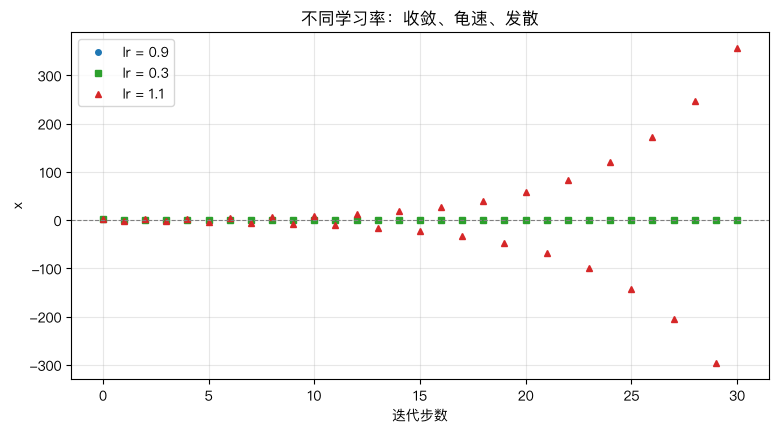

In [11]:
def gradient_descent(f, df, x0, lr, steps=30):
    xs = [x0]
    for _ in range(steps):
        x0 = x0 - lr * df(x0)          # 核心更新式：x ← x − η·f'(x)
        xs.append(x0)
    return np.array(xs)

f, df = lambda x: x**2, lambda x: 2*x   # 经典碗形损失

plt.figure(figsize=(9, 4.5))
for lr, marker, color in [(0.9, 'o', 'tab:blue'), (0.3, 's', 'tab:green'), (1.1, '^', 'tab:red')]:
    traj = gradient_descent(f, df, 1.5, lr)
    plt.plot(range(len(traj)), traj, marker, color=color, markersize=4, label=f'lr = {lr}')

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('迭代步数'); plt.ylabel('x')
plt.legend(); plt.grid(alpha=0.3)
plt.title('不同学习率：收敛、龟速、发散')


**三条轨迹说明了什么：**

- `lr = 0.9`：快速收敛到 0（最优解）
- `lr = 0.3`：收敛但慢，步子太小
- `lr = 1.1`：每一步越过最低点且幅度越来越大 → 发散

学习率是深度学习里最敏感的超参数之一，本质是"一阶泰勒近似在多大范围内可信"。第 6 课（梯度下降与优化）会系统分析动量、SGD 与学习率调度。


## 总结


| 本课数学工具 | 深度学习中的用途 |
|-------------|----------------|
| 导数（极限定义） | 理解"梯度"的根基：所有学习都源于一阶泰勒 |
| 求导法则 | 手工推导网络每一层的梯度公式 |
| 链式法则 | 反向传播的唯一数学原理 |
| 泰勒展开 | 梯度下降（一阶）/ 牛顿法、Hessian（二阶）的理论基础 |
| 数值微分 | 验证梯度正确性的梯度检查（gradient check） |
| autograd | 训练时真正使用的求导引擎 |

下一课《多元微积分与梯度》：把导数从"一个变量的斜率"推广到"多个变量的梯度向量"，走向真正的深度学习训练场景。


## 课后练习


1. **用极限定义推导** $(1/x)' = -1/x^2$，写出完整推导过程。
2. **用极限定义推导** $(\sin x)' = \cos x$（提示：$\sin(a+b) = \sin a \cos b + \cos a \sin b$，以及 $\lim_{h\to0} \sin h / h = 1$）。
3. **链式法则**：$y = \ln(x^2 + 3x)$，求 $dy/dx$，再用 autograd 验证。
4. **泰勒展开**：求 $e^x$ 在 $x_0 = 0$ 的三阶泰勒多项式，画出与原函数在 $[-1, 1]$ 上的误差曲线。
5. **数值微分**：对 $f(x) = x^5$ 在 $x = 1$ 处分别用前向差分和中心差分，$h$ 取 $10^{-2}, 10^{-4}, 10^{-6}, 10^{-8}$，比较误差，解释为什么 $h$ 太小误差反而变大。
6. **梯度下降**：用 $f(x) = (x-3)^2 + 1$，$lr = 0.5$，从 $x_0 = 0$ 出发迭代 10 步，打印每一步的 $x$，观察是否收敛到 3。
